In [1]:
import os
import re
import csv
import glob
from pathlib import Path
import pandas as pd

## Functions to organize the results

#### Process txt results

In [2]:


def extract_data_from_file(file_path):
    """Extract relevant data from a result file."""
    data = {}
    
    try:
        with open(file_path, 'r') as f:
            content = f.read()
            
            # Extract model type and data loading option
            model_match = re.search(r'Model type is (\w+)', content)
            data_loading_match = re.search(r'Data loading option is (\w+)', content)
            
            if model_match:
                data['model_type'] = model_match.group(1)
            if data_loading_match:
                data['data_loading_option'] = data_loading_match.group(1)
            
            # Extract test results
            global_results_match = re.search(r'The global test results: \[(.*?)\]', content)
            client_results_match = re.search(r'The client test results: \[(.*?)\]', content)
            avg_global_match = re.search(r'The average global test results: ([\d\.]+)', content)
            avg_client_match = re.search(r'The average client test results: ([\d\.]+)', content)
            std_global_match = re.search(r'The standard deviation global is: ([\d\.]+)', content)
            std_client_match = re.search(r'The standard deviation client is: ([\d\.]+)', content)
            
            if global_results_match:
                data['global_test_results'] = global_results_match.group(1)
            if client_results_match:
                data['client_test_results'] = client_results_match.group(1)
            if avg_global_match:
                data['avg_global_results'] = float(avg_global_match.group(1))
            if avg_client_match:
                data['avg_client_results'] = float(avg_client_match.group(1))
            if std_global_match:
                data['std_global'] = float(std_global_match.group(1))
            if std_client_match:
                data['std_client'] = float(std_client_match.group(1))
                
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        
    return data

def extract_metadata_from_path(path):
    """Extract dataset name, data splitting option, and model type from path."""
    metadata = {}
    
    # Extract from directory name
    dir_name = os.path.basename(os.path.dirname(path))
    parts = dir_name.split('_')
    
    if len(parts) >= 3:
        metadata['dataset'] = parts[0]
        metadata['data_splitting_option'] = parts[1]
        metadata['model_type'] = parts[2]
        
    return metadata

def main():
    results_dir = "/home/brian_bosho/FP/FP/results/results_20250228_145708"
    output_file = "extracted_results.csv"
    
    all_data = []
    
    # Walk through all subdirectories in the results folder
    for root, dirs, files in os.walk(results_dir):
        for file in files:
            if file.endswith(".txt") and file.startswith("results_"):
                file_path = os.path.join(root, file)
                
                # Extract data from file
                data = extract_data_from_file(file_path)
                
                # Extract metadata from path
                metadata = extract_metadata_from_path(file_path)
                
                # Combine data and metadata
                combined_data = {**data, **metadata, 'file_path': file_path}
                all_data.append(combined_data)
    
    # Write data to CSV
    if all_data:
        fieldnames = ['dataset', 'data_splitting_option', 'model_type', 
                     'avg_global_results', 'avg_client_results', 
                     'std_global', 'std_client', 'global_test_results', 
                     'client_test_results', 'file_path']
        
        with open(output_file, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            for data in all_data:
                # Only write fields that exist in the data
                filtered_data = {k: v for k, v in data.items() if k in fieldnames}
                writer.writerow(filtered_data)
        
        print(f"Results extracted to {output_file}")
    else:
        print("No data found.")

if __name__ == "__main__":
    main()
# extracted_results = pd.read_csv("/home/brian_bosho/FP/FP/extracted_results.csv")

No data found.


#### Extract from folders

In [3]:
import os
import re
import csv
import glob
from pathlib import Path
import pandas as pd

def extract_data_from_file(file_path):
    """Extract relevant data from a result file."""
    data = {}
    
    try:
        with open(file_path, 'r') as f:
            content = f.read()
            
            # Extract model type and data loading option
            model_match = re.search(r'Model type is (\w+)', content)
            data_loading_match = re.search(r'Data loading option is ([a-zA-Z_]+)', content)
            
            if model_match:
                data['model_type'] = model_match.group(1)
            if data_loading_match:
                data['data_loading_option'] = data_loading_match.group(1)
            
            # Extract test results
            global_results_match = re.search(r'The global test results: \[(.*?)\]', content)
            client_results_match = re.search(r'The client test results: \[(.*?)\]', content)
            avg_global_match = re.search(r'The average global test results: ([\d\.]+)', content)
            avg_client_match = re.search(r'The average client test results: ([\d\.]+)', content)
            std_global_match = re.search(r'The standard deviation global is: ([\d\.]+)', content)
            std_client_match = re.search(r'The standard deviation client is: ([\d\.]+)', content)
            
            if global_results_match:
                data['global_test_results'] = global_results_match.group(1)
            if client_results_match:
                data['client_test_results'] = client_results_match.group(1)
            if avg_global_match:
                data['avg_global_results'] = float(avg_global_match.group(1))
            if avg_client_match:
                data['avg_client_results'] = float(avg_client_match.group(1))
            if std_global_match:
                data['std_global'] = float(std_global_match.group(1))
            if std_client_match:
                data['std_client'] = float(std_client_match.group(1))
                
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        
    return data

def extract_metadata_from_filename(file_path):
    """Extract dataset name, data splitting option, and model type from filename."""
    metadata = {}
    
    # Extract from filename
    filename = os.path.basename(file_path)
    # Format: results_Dataset_split_option_Model_timestamp.txt
    match = re.search(r'results_([A-Za-z]+)_([a-zA-Z_]+)_([A-Za-z]+)_', filename)
    
    if match:
        metadata['dataset'] = match.group(1)
        metadata['data_splitting_option'] = match.group(2)
        metadata['model_type'] = match.group(3)
    else:
        # If not found in filename, try to extract from directory name
        dir_name = os.path.basename(os.path.dirname(file_path))
        parts = dir_name.split('_')
        
        if len(parts) >= 3:
            metadata['dataset'] = parts[0]
            # Handle the case where data_splitting_option might be multiple parts
            if 'with' in parts:
                with_index = parts.index('with')
                metadata['data_splitting_option'] = '_'.join(parts[1:with_index+2])
                if with_index + 2 < len(parts):
                    metadata['model_type'] = parts[with_index+2]
            else:
                metadata['data_splitting_option'] = parts[1]
                if len(parts) > 2:
                    metadata['model_type'] = parts[2]
        
    return metadata

def main():
    results_file = "/home/brian_bosho/FP/FP/results/results_20250228_145708"
    output_file = "extracted_results.csv"
    
    all_data = []
    
    # Find all result directories
    # result_dirs = glob.glob(os.path.join(results_dir, "results_*"))
    
    # for result_dir in result_file:
        # Find all dataset directories
    dataset_dirs = [d for d in glob.glob(os.path.join(results_file, "*")) if os.path.isdir(d)]
    
    for dataset_dir in dataset_dirs:
        # Find all result text files
        result_files = glob.glob(os.path.join(dataset_dir, "*.txt"))
        
        for file_path in result_files:
            # Extract data from file
            data = extract_data_from_file(file_path)
            
            # Extract metadata from filename
            metadata = extract_metadata_from_filename(file_path)
            
            # If model_type or data_loading_option wasn't found in file content
            # use the metadata from filename/directory name
            if 'model_type' not in data and 'model_type' in metadata:
                data['model_type'] = metadata['model_type']
            if 'data_loading_option' not in data and 'data_splitting_option' in metadata:
                data['data_loading_option'] = metadata['data_splitting_option']
            
            # Ensure dataset is included
            if 'dataset' not in data and 'dataset' in metadata:
                data['dataset'] = metadata['dataset']
            
            # Combine data and metadata
            combined_data = {**data, 'file_path': file_path}
            all_data.append(combined_data)

    # Write data to CSV
    if all_data:
        fieldnames = ['dataset', 'data_loading_option', 'model_type', 
                     'avg_global_results', 'avg_client_results', 
                     'std_global', 'std_client', 'global_test_results', 
                     'client_test_results', 'file_path']
        
        with open(output_file, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            for data in all_data:
                # Only write fields that exist in the data
                filtered_data = {k: v for k, v in data.items() if k in fieldnames}
                writer.writerow(filtered_data)
        
        print(f"Results extracted to {output_file}")
        
        # Also create a pandas DataFrame for easier analysis
        df = pd.DataFrame(all_data)
        summary_file = "results_summary.csv"
        df.to_csv(summary_file, index=False)
        print(f"Summary DataFrame saved to {summary_file}")
    else:
        print("No data found.")

if __name__ == "__main__":
    main()

No data found.


In [ ]:
df_summary = pd.read_csv("results_summary.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'results_summary.csv'

In [5]:
df_summary

NameError: name 'df_summary' is not defined

In [5]:
# find the colums fof the df_summary
print(df_summary.columns)
# lets create a reduced df with the columns: Dataset ,datasplitting optiomn, avg client results, std client results, model

NameError: name 'df_summary' is not defined

In [6]:
# lets create a reduced df with the columns: Dataset ,datasplitting optiomn, avg client results, std client results, model
reduced_df = df_summary[['dataset', 'data_loading_option', 'avg_client_results', 'std_client', 'model_type']]

# redice the data loading iptions to ld, fp & kh from the current name: split_dataset, split_dataset_with_khop, split_dataset_with_feature_prop
reduced_df['data_loading_option'] = reduced_df['data_loading_option'].replace(['split_dataset', 'split_dataset_with_khop', 'split_dataset_with_feature_prop'], ['LD', 'kH', 'FP'])
reduced_df.head()
# lets save the reduced df to a csv file
reduced_df.head()


NameError: name 'df_summary' is not defined

In [7]:
reduced_df

NameError: name 'reduced_df' is not defined

In [8]:
from matplotlib import pyplot as plt

In [9]:
# each dataset create a bar chart of the avg client results with x axis being the splitting option and y axis being the avg client results
def create_bar_chart(dataset, model_type):
    # filter the df for the dataset and model type
    df_dataset = reduced_df[(reduced_df['dataset'] == dataset) & (reduced_df['model_type'] == model_type)]
    # create a bar chart
    plt.bar(df_dataset['data_loading_option'], df_dataset['avg_client_results'])
    # tilt the x axis labels
    # make bars with diffent colors
    # add a title
    plt.title(f'{dataset} with {model_type}')
    # add a y label
    plt.ylabel('Average Client Results')
    # add a x label
    plt.xlabel('Data Loading Option')
    plt.show()
# create a bar chart for the dataset Cora with the model GCN
create_bar_chart('Cora', 'GCN')
# do the same for 




NameError: name 'reduced_df' is not defined

In [10]:
create_bar_chart('Citeseer', 'GCN')

NameError: name 'reduced_df' is not defined

In [11]:
# pubmed
create_bar_chart('Pubmed', 'GCN')
# citeseer
create_bar_chart('Citeseer', 'GCN')
# cora
create_bar_chart('Cora', 'GCN')


NameError: name 'reduced_df' is not defined

In [12]:
# do the same for GAT
create_bar_chart('Cora', 'GAT')
create_bar_chart('Citeseer', 'GAT')
create_bar_chart('Pubmed', 'GAT')




NameError: name 'reduced_df' is not defined

In [13]:
# for each fo the mmodels, lects calculate teh percentage difference for each of the data loading options


In [14]:
# lets create function that claculates the percntage differnce between LD and the other options for each dataset & model
def calculate_percentage_difference(dataset, model_type):
    # filter the df for the dataset and model type
    row = reduced_df[(reduced_df['dataset'] == dataset) & (reduced_df['model_type'] == model_type) & (reduced_df['data_loading_option'] == 'LD')]
    # get teh value of the base acc
    base_acc = row['avg_client_results'].values[0]
    fp_acc = reduced_df[(reduced_df['dataset'] == dataset) & (reduced_df['model_type'] == model_type) & (reduced_df['data_loading_option'] == 'FP')]['avg_client_results'].values[0]
    kh_acc = reduced_df[(reduced_df['dataset'] == dataset) & (reduced_df['model_type'] == model_type) & (reduced_df['data_loading_option'] == 'kH')]['avg_client_results'].values[0]

    # calculate the percentage difference
    fp_diff = ((fp_acc - base_acc) / base_acc) * 100
    kh_diff = ((kh_acc - base_acc) / base_acc) * 100

    # print(f"The percentage difference between LD and FP is {fp_diff}%")
    # print(f"The percentage difference between LD and kH is {kh_diff}%")

    return fp_diff, kh_diff

   



In [15]:
cora_gcn = calculate_percentage_difference('Cora', 'GCN')
cora_gat = calculate_percentage_difference('Cora', 'GAT')
citeseer_gcn = calculate_percentage_difference('Citeseer', 'GCN')
citeseer_gat = calculate_percentage_difference('Citeseer', 'GAT')
pubmed_gcn = calculate_percentage_difference('Pubmed', 'GCN')
pubmed_gat = calculate_percentage_difference('Pubmed', 'GAT')


NameError: name 'reduced_df' is not defined

In [16]:
print(f"The percentage difference between LD and FP for Cora GCN is {cora_gcn[0]}%")
print(f"The percentage difference between LD and kH for Cora GCN is {cora_gcn[1]}%")
print(f"The percentage difference between LD and FP for Cora GAT is {cora_gat[0]}%")
print(f"The percentage difference between LD and kH for Cora GAT is {cora_gat[1]}%")




NameError: name 'cora_gcn' is not defined

In [17]:
print(f"The percentage difference between LD and FP for Citeseer GCN is {citeseer_gcn[0]}%")
print(f"The percentage difference between LD and kH for Citeseer GCN is {citeseer_gcn[1]}%")
print(f"The percentage difference between LD and FP for Citeseer GAT is {citeseer_gat[0]}%")
print(f"The percentage difference between LD and kH for Citeseer GAT is {citeseer_gat[1]}%")



NameError: name 'citeseer_gcn' is not defined

In [18]:
print(f"The percentage difference between LD and FP for Pubmed GCN is {pubmed_gcn[0]}%")
print(f"The percentage difference between LD and kH for Pubmed GCN is {pubmed_gcn[1]}%")
print(f"The percentage difference between LD and FP for Pubmed GAT is {pubmed_gat[0]}%")
print(f"The percentage difference between LD and kH for Pubmed GAT is {pubmed_gat[1]}%")



NameError: name 'pubmed_gcn' is not defined

### Functions to plot the results

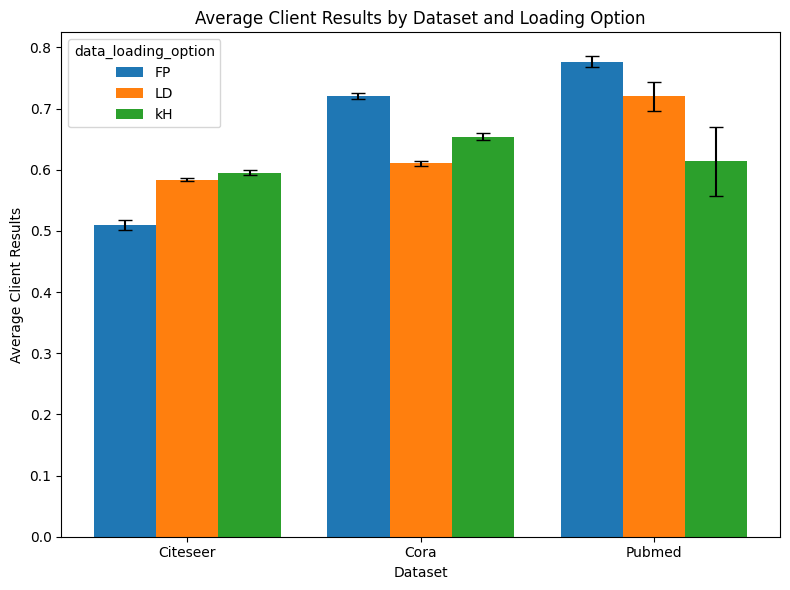

Results Table:
data_loading_option             FP             LD             kH
dataset                                                         
Citeseer             0.510 ± 0.008  0.583 ± 0.002  0.595 ± 0.005
Cora                 0.720 ± 0.005  0.611 ± 0.004  0.654 ± 0.006
Pubmed               0.777 ± 0.009  0.720 ± 0.023  0.613 ± 0.057


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_client_results(
    df, 
    dataset_col="dataset", 
    option_col="data_loading_option", 
    avg_col="avg_client_results", 
    std_col="std_client",
    chart_title="Average Client Results by Dataset and Loading Option",
    xlabel="Dataset",
    ylabel="Average Client Results",
    order_options=None,   # if None, sorted unique values will be used
    order_datasets=None,  # if None, sorted unique datasets will be used
    fig_size=(8,6),
    show_plot=True
):
    """
    Groups the input dataframe by dataset and loading option (using the provided column names),
    computes the mean of the average and standard deviation values, and produces:
    
    1) A grouped bar chart with error bars.
    2) A pivot table where each cell is formatted as "avg ± std".

    Parameters:
    - df: The input DataFrame.
    - dataset_col: Column name for dataset.
    - option_col: Column name for loading options.
    - avg_col: Column name for average results.
    - std_col: Column name for standard deviation.
    - chart_title, xlabel, ylabel: Strings for chart labeling.
    - order_options: Optional list to specify ordering of loading options.
    - order_datasets: Optional list to specify ordering of datasets.
    - fig_size: Tuple to specify the size of the matplotlib figure.
    - show_plot: Boolean to decide if plt.show() should be called.

    Returns:
    - result_table: A pivot table DataFrame with formatted "avg ± std" values.
    """

    # Standardize the option column values to strings (e.g., to handle case sensitivity)
    df[option_col] = df[option_col].astype(str)
    
    # Group by dataset and loading option, and compute means for avg and std
    grouped = df.groupby([dataset_col, option_col]).agg({
        avg_col: "mean",
        std_col: "mean"
    }).reset_index()
    
    # Determine ordering if not provided
    if order_options is None:
        order_options = sorted(grouped[option_col].unique())
    if order_datasets is None:
        order_datasets = sorted(grouped[dataset_col].unique())
    
    # Create a new column that formats the result as "avg ± std"
    grouped["result_str"] = grouped.apply(
        lambda row: f"{row[avg_col]:.3f} ± {row[std_col]:.3f}", axis=1
    )
    
    # Create a pivot table for the results table
    result_table = grouped.pivot(index=dataset_col, columns=option_col, values="result_str")
    result_table = result_table.reindex(columns=order_options)
    
    # Prepare the data for plotting: pivot to get numeric values
    pivot_numeric = grouped.pivot(index=dataset_col, columns=option_col)
    avg_data = pivot_numeric[avg_col].reindex(order_datasets).reindex(columns=order_options)
    std_data = pivot_numeric[std_col].reindex(order_datasets).reindex(columns=order_options)
    
    # Set up the bar chart parameters
    x = np.arange(len(order_datasets))  # positions for datasets
    width = 0.8 / len(order_options)  # bar width, adjusted based on number of options
    
    fig, ax = plt.subplots(figsize=fig_size)
    
    for i, option in enumerate(order_options):
        values = avg_data[option]
        errors = std_data[option]
        ax.bar(x + i * width, values, width, yerr=errors, capsize=5, label=option)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(chart_title)
    ax.set_xticks(x + width * (len(order_options)-1) / 2)
    ax.set_xticklabels(order_datasets)
    ax.legend(title=option_col)
    
    plt.tight_layout()
    if show_plot:
        plt.show()
    
    return result_table

# --- Sample usage ---
if __name__ == "__main__":
    # Example DataFrame
    data = {
        "dataset": ["Citeseer", "Cora", "Pubmed", "Citeseer", "Cora", "Citeseer", "Pubmed", "Cora", "Cora", "Cora",
                    "Pubmed", "Citeseer", "Pubmed", "Pubmed", "Citeseer", "Citeseer", "Cora", "Pubmed"],
        "data_loading_option": ["LD", "kH", "LD", "kH", "FP", "kH", "FP", "LD", "kH", "LD",
                                "LD", "FP", "kH", "FP", "LD", "FP", "FP", "kH"],
        "avg_client_results": [0.614921, 0.651326, 0.691414, 0.598590, 0.717688, 0.592352, 0.777658, 0.632224,
                               0.656579, 0.589714, 0.749047, 0.506083, 0.623059, 0.775815, 0.551824, 0.513958,
                               0.723095, 0.603874],
        "std_client": [0.003430, 0.005179, 0.043085, 0.003607, 0.003577, 0.005954, 0.005778, 0.002890,
                       0.006303, 0.005199, 0.003819, 0.012014, 0.012287, 0.011504, 0.001556, 0.004552,
                       0.006471, 0.100978],
        "model_type": ["GCN", "GCN", "GAT", "GCN", "GCN", "GAT", "GCN", "GCN", "GAT", "GAT",
                       "GCN", "GAT", "GCN", "GAT", "GAT", "GCN", "GAT", "GAT"]
    }
    sample_df = pd.DataFrame(data)
    
    # Call the function with the sample DataFrame.
    results_table = plot_client_results(sample_df)
    print("Results Table:")
    print(results_table)


### Read data from the Json files

In [20]:
import os
import json
import pandas as pd
from glob import glob

def extract_data_from_json(json_file):
    """Extract relevant data from a JSON result file and format it for DataFrame."""
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Extract experiment configuration
    config = data['experiment_config']
    
    # Extract summary statistics
    summary = data['summary']
    
    # Build a dictionary with all the data we want to include
    row_data = {
        # Configuration data
        'device': config.get('device', None),
        'data_loading_option': config.get('data_loading_option', None),
        'model_type': config.get('model_type', None),
        'dataset': config.get('dataset', None),
        'num_clients': config.get('num_clients', None),
        'beta': config.get('beta', None),
        'hop': config.get('hop', None),
        
        # Summary statistics
        'avg_global_result': summary.get('average_global_result', None),
        'avg_client_result': summary.get('average_client_result', None),
        'std_global': summary.get('std_global', None),
        'std_client': summary.get('std_client', None),
        
        # Additional metadata
        'experiment_subfolder': os.path.basename(os.path.dirname(json_file)),
        'json_filename': os.path.basename(json_file)
    }
    
    # Extract the last round results
    if data.get('rounds'):
        last_round = data['rounds'][-1]
        row_data['final_round'] = last_round.get('round', None)
        row_data['final_global_result'] = last_round.get('global_result', None)
        row_data['final_client_result'] = last_round.get('client_result', None)
    
    # Parse experiment parameters from the folder name
    folder_parts = row_data['experiment_subfolder'].split('_')
    if len(folder_parts) >= 3:
        # Override dataset and model_type if we can extract from folder name
        # This acts as a cross-check against the JSON data
        for part in folder_parts:
            if part in ['Citeseer', 'Cora', 'Pubmed']:
                row_data['dataset_from_folder'] = part
            if part in ['GAT', 'GCN']:
                row_data['model_type_from_folder'] = part
            if part in ['split_dataset', 'with_feature_prop', 'with_khop']:
                row_data['data_loading_from_folder'] = part
    
    return row_data

def process_results_folder(results_folder):
    """Process a specific results folder and extract data from all JSON files."""
    all_data = []
    
    # Get all experiment subfolders (Citeseer_split_dataset_GAT, etc.)
    experiment_dirs = [d for d in os.listdir(results_folder) 
                      if os.path.isdir(os.path.join(results_folder, d))]
    
    for exp_dir in experiment_dirs:
        exp_path = os.path.join(results_folder, exp_dir)
        
        # Find all JSON result files in this experiment subfolder
        json_files = glob(os.path.join(exp_path, "*results*.json"))
        
        for json_file in json_files:
            try:
                row_data = extract_data_from_json(json_file)
                all_data.append(row_data)
                print(f"Processed: {json_file}")
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
    
    # Convert to DataFrame
    if all_data:
        df = pd.DataFrame(all_data)
        return df
    else:
        print("No data found in the results folder.")
        return pd.DataFrame()

def get_results_df(results_folder):
    # Specific results folder to process
    results_folder = "/home/brian_bosho/FP/FP/old1_results/results_20250302_094016"
    
    # Check if the folder exists
    if not os.path.exists(results_folder):
        print(f"Error: The folder '{results_folder}' does not exist.")
        return
    
    # Process the results folder and create DataFrame
    results_df = process_results_folder(results_folder)
    
    if not results_df.empty:
        # Save the DataFrame to CSV
        output_file = f"{os.path.basename(results_folder)}_summary.csv"
        results_df.to_csv(output_file, index=False)
        
        print(f"Successfully processed {len(results_df)} result files.")
        print(f"DataFrame shape: {results_df.shape}")
        print(f"Results saved to {output_file}")
        print("First few rows of the DataFrame:")
        print(results_df.head())
    else:
        print("No data was processed.")

    return results_df


def main():
    # Specific results folder to process
    results_folder = "/home/brian_bosho/FP/FP/old1_results/results_20250302_094016"
    
    # Check if the folder exists
    if not os.path.exists(results_folder):
        print(f"Error: The folder '{results_folder}' does not exist.")
        return
    
    # Process the results folder and create DataFrame
    results_df = process_results_folder(results_folder)
    
    if not results_df.empty:
        # Save the DataFrame to CSV
        output_file = f"{os.path.basename(results_folder)}_summary.csv"
        results_df.to_csv(output_file, index=False)
        
        print(f"Successfully processed {len(results_df)} result files.")
        print(f"DataFrame shape: {results_df.shape}")
        print(f"Results saved to {output_file}")
        print("First few rows of the DataFrame:")
        print(results_df.head())
    else:
        print("No data was processed.")

if __name__ == "__main__":
    main()

Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Citeseer_split_dataset_GCN/results_Citeseer_split_dataset_GCN_20250302_094406.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Cora_split_dataset_with_khop_GCN/results_Cora_split_dataset_with_khop_GCN_20250302_094151.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Pubmed_split_dataset_GAT/results_Pubmed_split_dataset_GAT_20250302_094826.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Citeseer_split_dataset_with_khop_GCN/results_Citeseer_split_dataset_with_khop_GCN_20250302_094519.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Cora_split_dataset_with_feature_prop_GCN/results_Cora_split_dataset_with_feature_prop_GCN_20250302_094258.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Citeseer_split_dataset_with_khop_GAT/results_Citeseer_split_dataset_with_khop_GAT_20250302_094600

### Using the functions

In [21]:
results_folder = "/home/brian_bosho/FP/FP/old1_results/results_20250302_094016"
results_df = get_results_df(results_folder)
results_df

Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Citeseer_split_dataset_GCN/results_Citeseer_split_dataset_GCN_20250302_094406.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Cora_split_dataset_with_khop_GCN/results_Cora_split_dataset_with_khop_GCN_20250302_094151.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Pubmed_split_dataset_GAT/results_Pubmed_split_dataset_GAT_20250302_094826.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Citeseer_split_dataset_with_khop_GCN/results_Citeseer_split_dataset_with_khop_GCN_20250302_094519.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Cora_split_dataset_with_feature_prop_GCN/results_Cora_split_dataset_with_feature_prop_GCN_20250302_094258.json
Processed: /home/brian_bosho/FP/FP/old1_results/results_20250302_094016/Citeseer_split_dataset_with_khop_GAT/results_Citeseer_split_dataset_with_khop_GAT_20250302_094600

,device,data_loading_option,model_type,dataset,num_clients,beta,hop,avg_global_result,avg_client_result,std_global,std_client,experiment_subfolder,json_filename,final_round,final_global_result,final_client_result,dataset_from_folder,model_type_from_folder
0,cuda,split_dataset,GCN,Citeseer,10,1,2,0.6672,0.605858,0.008750,0.009053,Citeseer_split_dataset_GCN,results_Citeseer_split_dataset_GCN_20250302_09...,5,0.679,0.614405,Citeseer,GCN
1,cuda,split_dataset_with_khop,GCN,Cora,10,1,2,0.4352,0.349321,0.045137,0.039068,Cora_split_dataset_with_khop_GCN,results_Cora_split_dataset_with_khop_GCN_20250...,5,0.443,0.324120,Cora,GCN
2,cuda,split_dataset,GAT,Pubmed,10,1,2,0.1800,0.198338,0.000000,0.001030,Pubmed_split_dataset_GAT,results_Pubmed_split_dataset_GAT_20250302_0948...,5,0.180,0.197653,Pubmed,GAT
3,cuda,split_dataset_with_khop,GCN,Citeseer,10,1,2,0.6172,0.494128,0.022319,0.016263,Citeseer_split_dataset_with_khop_GCN,results_Citeseer_split_dataset_with_khop_GCN_2...,5,0.578,0.478779,Citeseer,GCN
4,cuda,split_dataset_with_feature_prop,GCN,Cora,10,1,2,0.6070,0.612236,0.035225,0.028682,Cora_split_dataset_with_feature_prop_GCN,results_Cora_split_dataset_with_feature_prop_G...,5,0.603,0.599248,Cora,GCN
5,cuda,split_dataset_with_khop,GAT,Citeseer,10,1,2,0.6514,0.535603,0.013994,0.010155,Citeseer_split_dataset_with_khop_GAT,results_Citeseer_split_dataset_with_khop_GAT_2...,5,0.671,0.526603,Citeseer,GAT
6,cuda,split_dataset_with_feature_prop,GCN,Pubmed,10,1,2,0.1806,0.197882,0.001200,0.000000,Pubmed_split_dataset_with_feature_prop_GCN,results_Pubmed_split_dataset_with_feature_prop...,5,0.180,0.197882,Pubmed,GCN
7,cuda,split_dataset,GCN,Cora,10,1,2,0.5924,0.519353,0.072090,0.044725,Cora_split_dataset_GCN,results_Cora_split_dataset_GCN_20250302_094047...,5,0.539,0.476058,Cora,GCN
8,cuda,split_dataset_with_khop,GAT,Cora,10,1,2,0.5632,0.397460,0.016952,0.029527,Cora_split_dataset_with_khop_GAT,results_Cora_split_dataset_with_khop_GAT_20250...,5,0.546,0.403383,Cora,GAT
9,cuda,split_dataset,GAT,Cora,10,1,2,0.6812,0.555685,0.005776,0.017733,Cora_split_dataset_GAT,results_Cora_split_dataset_GAT_20250302_094119...,5,0.683,0.543760,Cora,GAT


In [22]:
# rename avg_client_result to avg_client_results
results_df.rename(columns={"avg_client_result": "avg_client_results"}, inplace=True)


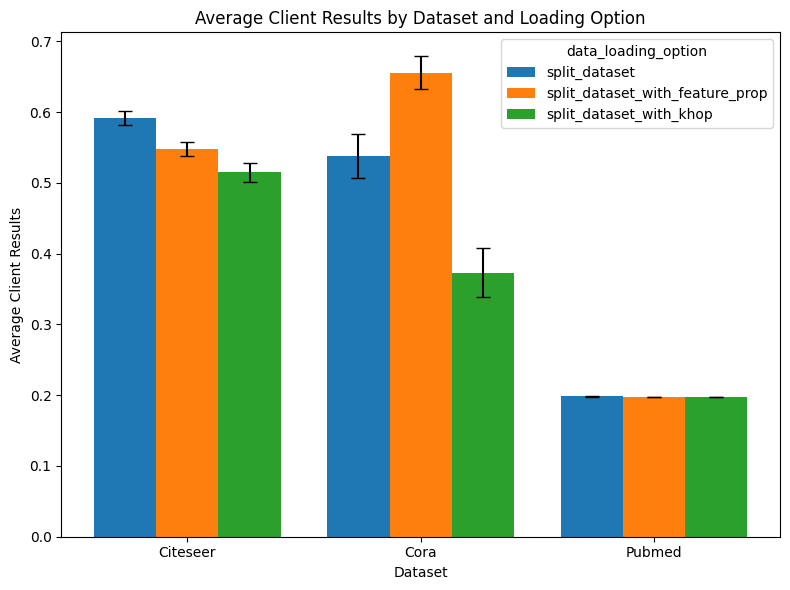

Results Table:


data_loading_option,split_dataset,split_dataset_with_feature_prop,split_dataset_with_khop
dataset,,,
Citeseer,0.592 ± 0.010,0.548 ± 0.010,0.515 ± 0.013
Cora,0.538 ± 0.031,0.656 ± 0.023,0.373 ± 0.034
Pubmed,0.198 ± 0.001,0.198 ± 0.000,0.198 ± 0.000


In [23]:
    # Call the function with the sample DataFrame.
results_table = plot_client_results(results_df)
print("Results Table:")
results_table

In [24]:
# read txt files


In [25]:
latest_data_path = "/home/brian_bosho/FP/FP/results/results_20250312_040242"

In [26]:
df_latest = process_results_folder(latest_data_path)
df_latest






FileNotFoundError: [Errno 2] No such file or directory: '/home/brian_bosho/FP/FP/results/results_20250312_040242'

In [27]:
# rename avg_client_result to avg_client_results
df_latest.rename(columns={"avg_client_result": "avg_client_results"}, inplace=True)

# Call the function with the sample DataFrame.
results_table = plot_client_results(df_latest)
print("Results Table:")
results_table

NameError: name 'df_latest' is not defined

In [28]:
# lets transpose the results table
results_table = results_table.T
results_table


dataset,Citeseer,Cora,Pubmed
data_loading_option,,,
split_dataset,0.592 ± 0.010,0.538 ± 0.031,0.198 ± 0.001
split_dataset_with_feature_prop,0.548 ± 0.010,0.656 ± 0.023,0.198 ± 0.000
split_dataset_with_khop,0.515 ± 0.013,0.373 ± 0.034,0.198 ± 0.000


In [29]:
main_results_folder = "/home/brian_bosho/FP/FP/results/results_20250312_052154"
df_main = process_results_folder(main_results_folder)
df_main

# rename avg_client_result to avg_client_results
df_main.rename(columns={"avg_client_result": "avg_client_results"}, inplace=True)
df_main


FileNotFoundError: [Errno 2] No such file or directory: '/home/brian_bosho/FP/FP/results/results_20250312_052154'

In [30]:
# plot the results table
results_table = plot_client_results(df_main)
print("Results Table:")
results_table

NameError: name 'df_main' is not defined

In [31]:
# lets transpose the results table
results_table = results_table.T
results_table





data_loading_option,split_dataset,split_dataset_with_feature_prop,split_dataset_with_khop
dataset,,,
Citeseer,0.592 ± 0.010,0.548 ± 0.010,0.515 ± 0.013
Cora,0.538 ± 0.031,0.656 ± 0.023,0.373 ± 0.034
Pubmed,0.198 ± 0.001,0.198 ± 0.000,0.198 ± 0.000


In [32]:
pubmed_result= "/home/brian_bosho/FP/FP/results/results_20250312_062010"
df_pubmed = process_results_folder(pubmed_result)
df_pubmed

# rename avg_client_result to avg_client_results
df_pubmed.rename(columns={"avg_client_result": "avg_client_results"}, inplace=True)
df_pubmed

FileNotFoundError: [Errno 2] No such file or directory: '/home/brian_bosho/FP/FP/results/results_20250312_062010'

In [33]:
# plot the results table
results_table = plot_client_results(df_pubmed)
print("Results Table:")
results_table
# lets transpose the results table
results_table = results_table.T
results_table


NameError: name 'df_pubmed' is not defined

In [34]:
pubmed_2hop = "/home/brian_bosho/FP/FP/results/results_20250312_114232"
df_pubmed_2hop = process_results_folder(pubmed_2hop)
df_pubmed_2hop


FileNotFoundError: [Errno 2] No such file or directory: '/home/brian_bosho/FP/FP/results/results_20250312_114232'

In [35]:
# rename avg_client_result to avg_client_results
df_pubmed_2hop.rename(columns={"avg_client_result": "avg_client_results"}, inplace=True)
df_pubmed_2hop
# plot the results table
results_table = plot_client_results(df_pubmed_2hop)
print("Results Table:")
results_table


NameError: name 'df_pubmed_2hop' is not defined

### Overall results IID

In [36]:
iid_folder = "/home/brian_bosho/FP/FP/results/results_20250312_122203"
df_iid = process_results_folder(iid_folder)
df_iid

# rename avg_client_result to avg_client_results
df_iid.rename(columns={"avg_client_result": "avg_client_results"}, inplace=True)
df_iid

Processed: /home/brian_bosho/FP/FP/results/results_20250312_122203/Cora_adjacency_GCN/results_Cora_adjacency_GCN_20250312_123154.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_122203/Citeseer_zero_GCN/results_Citeseer_zero_GCN_20250312_124230.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_122203/Pubmed_zero_GCN/results_Pubmed_zero_GCN_20250312_130120.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_122203/Citeseer_adjacency_GCN/results_Citeseer_adjacency_GCN_20250312_124936.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_122203/Cora_zero_hop_GCN/results_Cora_zero_hop_GCN_20250312_122358.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_122203/Citeseer_propagation_GCN/results_Citeseer_propagation_GCN_20250312_124453.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_122203/Citeseer_diffusion_GCN/results_Citeseer_diffusion_GCN_20250312_125201.json
Processed: /home/brian_bosho/FP/FP/results/r

,device,data_loading_option,model_type,dataset,num_clients,beta,hop,avg_global_result,avg_client_results,std_global,std_client,experiment_subfolder,json_filename,final_round,final_global_result,final_client_result,dataset_from_folder,model_type_from_folder
0,cuda,adjacency,GCN,Cora,10,1,2,0.8062,0.789718,0.003709,0.004979,Cora_adjacency_GCN,results_Cora_adjacency_GCN_20250312_123154.json,5,0.807,0.788021,Cora,GCN
1,cuda,zero,GCN,Citeseer,10,1,2,0.6918,0.622458,0.004833,0.010515,Citeseer_zero_GCN,results_Citeseer_zero_GCN_20250312_124230.json,5,0.692,0.610934,Citeseer,GCN
2,cuda,zero,GCN,Pubmed,10,1,2,0.7040,0.692120,0.020513,0.033032,Pubmed_zero_GCN,results_Pubmed_zero_GCN_20250312_130120.json,5,0.699,0.668061,Pubmed,GCN
3,cuda,adjacency,GCN,Citeseer,10,1,2,0.6976,0.664422,0.003720,0.004255,Citeseer_adjacency_GCN,results_Citeseer_adjacency_GCN_20250312_124936...,5,0.700,0.662249,Citeseer,GCN
4,cuda,zero_hop,GCN,Cora,10,1,2,0.7776,0.674314,0.011110,0.012572,Cora_zero_hop_GCN,results_Cora_zero_hop_GCN_20250312_122358.json,5,0.770,0.663019,Cora,GCN
5,cuda,propagation,GCN,Citeseer,10,1,2,0.6790,0.613790,0.004147,0.009279,Citeseer_propagation_GCN,results_Citeseer_propagation_GCN_20250312_1244...,5,0.685,0.622240,Citeseer,GCN
6,cuda,diffusion,GCN,Citeseer,10,1,2,0.6966,0.662580,0.006280,0.004843,Citeseer_diffusion_GCN,results_Citeseer_diffusion_GCN_20250312_125201...,5,0.698,0.664068,Citeseer,GCN
7,cuda,efficient,GCN,Citeseer,10,1,2,0.6938,0.662225,0.004622,0.008067,Citeseer_efficient_GCN,results_Citeseer_efficient_GCN_20250312_125649...,5,0.690,0.668663,Citeseer,GCN
8,cuda,random_walk,GCN,Cora,10,1,2,0.8042,0.784442,0.002713,0.006738,Cora_random_walk_GCN,results_Cora_random_walk_GCN_20250312_123555.json,5,0.804,0.784824,Cora,GCN
9,cuda,random_walk,GCN,Citeseer,10,1,2,0.6968,0.666728,0.003655,0.007989,Citeseer_random_walk_GCN,results_Citeseer_random_walk_GCN_20250312_1254...,5,0.695,0.657572,Citeseer,GCN


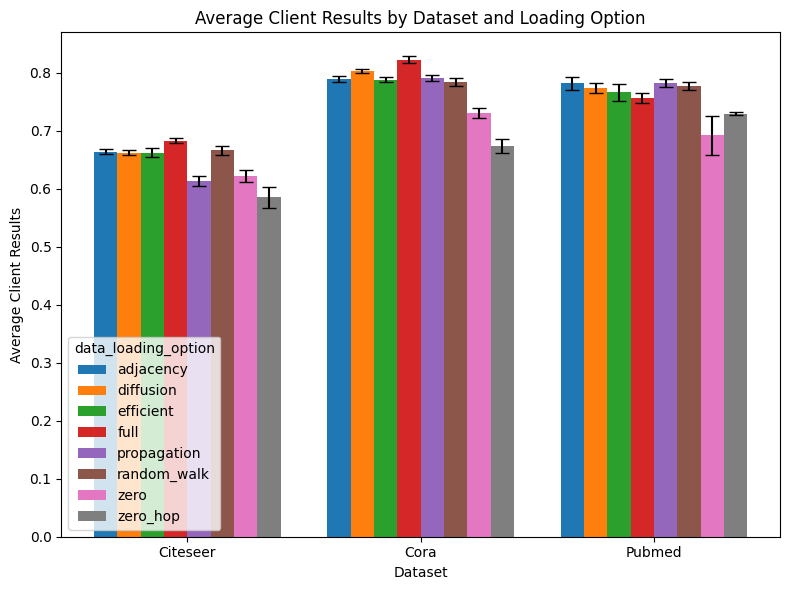

Results Table:


dataset,Citeseer,Cora,Pubmed
data_loading_option,,,
adjacency,0.664 ± 0.004,0.790 ± 0.005,0.782 ± 0.011
diffusion,0.663 ± 0.005,0.803 ± 0.003,0.773 ± 0.009
efficient,0.662 ± 0.008,0.788 ± 0.004,0.766 ± 0.014
full,0.683 ± 0.005,0.823 ± 0.006,0.756 ± 0.008
propagation,0.614 ± 0.009,0.792 ± 0.005,0.783 ± 0.007
random_walk,0.667 ± 0.008,0.784 ± 0.007,0.777 ± 0.007
zero,0.622 ± 0.011,0.731 ± 0.008,0.692 ± 0.033
zero_hop,0.585 ± 0.018,0.674 ± 0.013,0.730 ± 0.002


In [37]:
# plot the results table
results_table = plot_client_results(df_iid)
print("Results Table:")
results_table
# lets transpose the results table
results_table = results_table.T
results_table


In [47]:
# check the df columns
df_iid.columns
# lets filter results to keep the folowwing: data loading options: full, zero hop & adjacency
df_iid_filtered = df_iid[df_iid['data_loading_option'].isin(['full', 'zero_hop', 'adjacency'])]
df_iid_filtered

# rename adjacency to FP, rename zero_hop to 0-hop 
df_iid_filtered['data_loading_option'] = df_iid_filtered['data_loading_option'].replace({'adjacency': 'FP', 'zero_hop': '0-hop'})

df_iid_filtered




/tmp/ipykernel_3690687/1732725628.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iid_filtered['data_loading_option'] = df_iid_filtered['data_loading_option'].replace({'adjacency': 'FP', 'zero_hop': '0-hop'})


,device,data_loading_option,model_type,dataset,num_clients,beta,hop,avg_global_result,avg_client_results,std_global,std_client,experiment_subfolder,json_filename,final_round,final_global_result,final_client_result,dataset_from_folder,model_type_from_folder
0,cuda,FP,GCN,Cora,10,1,2,0.8062,0.789718,0.003709,0.004979,Cora_adjacency_GCN,results_Cora_adjacency_GCN_20250312_123154.json,5,0.807,0.788021,Cora,GCN
3,cuda,FP,GCN,Citeseer,10,1,2,0.6976,0.664422,0.003720,0.004255,Citeseer_adjacency_GCN,results_Citeseer_adjacency_GCN_20250312_124936...,5,0.700,0.662249,Citeseer,GCN
4,cuda,0-hop,GCN,Cora,10,1,2,0.7776,0.674314,0.011110,0.012572,Cora_zero_hop_GCN,results_Cora_zero_hop_GCN_20250312_122358.json,5,0.770,0.663019,Cora,GCN
12,cuda,full,GCN,Cora,10,1,2,0.8158,0.822996,0.005946,0.005612,Cora_full_GCN,results_Cora_full_GCN_20250312_122954.json,5,0.826,0.821961,Cora,GCN
13,cuda,full,GCN,Pubmed,10,1,2,0.7530,0.756149,0.003406,0.008446,Pubmed_full_GCN,results_Pubmed_full_GCN_20250312_130623.json,5,0.755,0.746856,Pubmed,GCN
16,cuda,full,GCN,Citeseer,10,1,2,0.6932,0.683289,0.004400,0.004515,Citeseer_full_GCN,results_Citeseer_full_GCN_20250312_124714.json,5,0.693,0.682241,Citeseer,GCN
18,cuda,FP,GCN,Pubmed,10,1,2,0.7506,0.782042,0.009024,0.011255,Pubmed_adjacency_GCN,results_Pubmed_adjacency_GCN_20250312_130855.json,5,0.761,0.785382,Pubmed,GCN
20,cuda,0-hop,GCN,Citeseer,10,1,2,0.6718,0.585374,0.013075,0.018332,Citeseer_zero_hop_GCN,results_Citeseer_zero_hop_GCN_20250312_124007....,5,0.686,0.594674,Citeseer,GCN
23,cuda,0-hop,GCN,Pubmed,10,1,2,0.7440,0.730015,0.018526,0.002051,Pubmed_zero_hop_GCN,results_Pubmed_zero_hop_GCN_20250312_125849.json,5,0.716,0.730780,Pubmed,GCN


/tmp/ipykernel_3690687/2981493629.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[option_col] = df[option_col].astype(str)


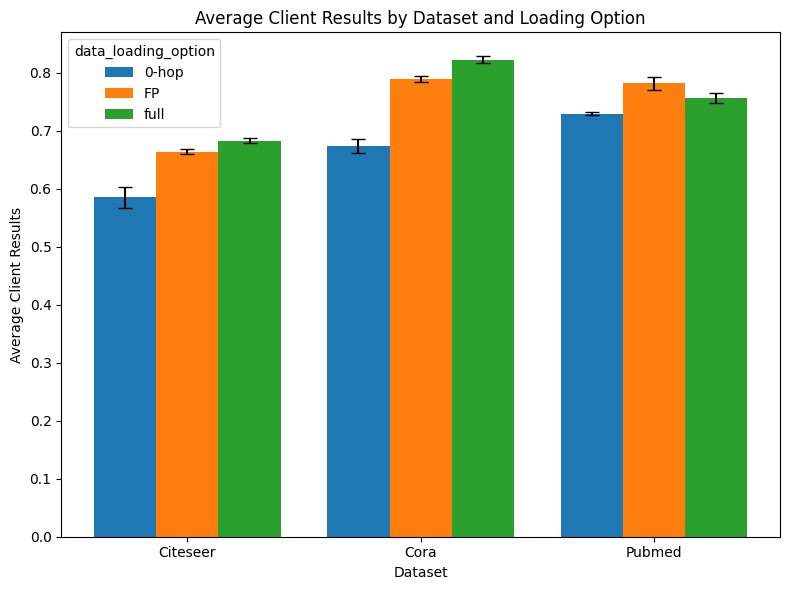

Results Table:


data_loading_option,0-hop,FP,full
dataset,,,
Citeseer,0.585 ± 0.018,0.664 ± 0.004,0.683 ± 0.005
Cora,0.674 ± 0.013,0.790 ± 0.005,0.823 ± 0.006
Pubmed,0.730 ± 0.002,0.782 ± 0.011,0.756 ± 0.008


In [48]:
# plot the results table
results_table = plot_client_results(df_iid_filtered)
print("Results Table:")
results_table

### Now IID

In [39]:
iid_folder2 = "/home/brian_bosho/FP/FP/results/results_20250312_131943"
df_iid_2 = process_results_folder(iid_folder2)
df_iid_2

# rename avg_client_result to avg_client_results
df_iid_2.rename(columns={"avg_client_result": "avg_client_results"}, inplace=True)
df_iid_2



Processed: /home/brian_bosho/FP/FP/results/results_20250312_131943/Cora_adjacency_GCN/results_Cora_adjacency_GCN_20250312_132935.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_131943/Citeseer_zero_GCN/results_Citeseer_zero_GCN_20250312_134015.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_131943/Pubmed_zero_GCN/results_Pubmed_zero_GCN_20250312_135919.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_131943/Citeseer_adjacency_GCN/results_Citeseer_adjacency_GCN_20250312_134727.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_131943/Cora_zero_hop_GCN/results_Cora_zero_hop_GCN_20250312_132138.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_131943/Citeseer_propagation_GCN/results_Citeseer_propagation_GCN_20250312_134240.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_131943/Citeseer_diffusion_GCN/results_Citeseer_diffusion_GCN_20250312_134953.json
Processed: /home/brian_bosho/FP/FP/results/r

,device,data_loading_option,model_type,dataset,num_clients,beta,hop,avg_global_result,avg_client_results,std_global,std_client,experiment_subfolder,json_filename,final_round,final_global_result,final_client_result,dataset_from_folder,model_type_from_folder
0,cuda,adjacency,GCN,Cora,10,10000,2,0.7896,0.725899,0.001855,0.004784,Cora_adjacency_GCN,results_Cora_adjacency_GCN_20250312_132935.json,5,0.788,0.731127,Cora,GCN
1,cuda,zero,GCN,Citeseer,10,10000,2,0.6780,0.592635,0.006066,0.009863,Citeseer_zero_GCN,results_Citeseer_zero_GCN_20250312_134015.json,5,0.678,0.595420,Citeseer,GCN
2,cuda,zero,GCN,Pubmed,10,10000,2,0.7208,0.628524,0.033843,0.082794,Pubmed_zero_GCN,results_Pubmed_zero_GCN_20250312_135919.json,5,0.738,0.663089,Pubmed,GCN
3,cuda,adjacency,GCN,Citeseer,10,10000,2,0.6852,0.648422,0.004167,0.007067,Citeseer_adjacency_GCN,results_Citeseer_adjacency_GCN_20250312_134727...,5,0.689,0.655505,Citeseer,GCN
4,cuda,zero_hop,GCN,Cora,10,10000,2,0.7716,0.610613,0.010670,0.009967,Cora_zero_hop_GCN,results_Cora_zero_hop_GCN_20250312_132138.json,5,0.762,0.598485,Cora,GCN
5,cuda,propagation,GCN,Citeseer,10,10000,2,0.6190,0.481240,0.006603,0.010677,Citeseer_propagation_GCN,results_Citeseer_propagation_GCN_20250312_1342...,5,0.624,0.489382,Citeseer,GCN
6,cuda,diffusion,GCN,Citeseer,10,10000,2,0.6810,0.637656,0.010060,0.012611,Citeseer_diffusion_GCN,results_Citeseer_diffusion_GCN_20250312_134953...,5,0.684,0.655787,Citeseer,GCN
7,cuda,efficient,GCN,Citeseer,10,10000,2,0.6872,0.645543,0.005776,0.006278,Citeseer_efficient_GCN,results_Citeseer_efficient_GCN_20250312_135443...,5,0.687,0.652564,Citeseer,GCN
8,cuda,random_walk,GCN,Cora,10,10000,2,0.7886,0.719247,0.004758,0.006662,Cora_random_walk_GCN,results_Cora_random_walk_GCN_20250312_133337.json,5,0.795,0.720885,Cora,GCN
9,cuda,random_walk,GCN,Citeseer,10,10000,2,0.6854,0.634198,0.005987,0.006721,Citeseer_random_walk_GCN,results_Citeseer_random_walk_GCN_20250312_1352...,5,0.690,0.636186,Citeseer,GCN


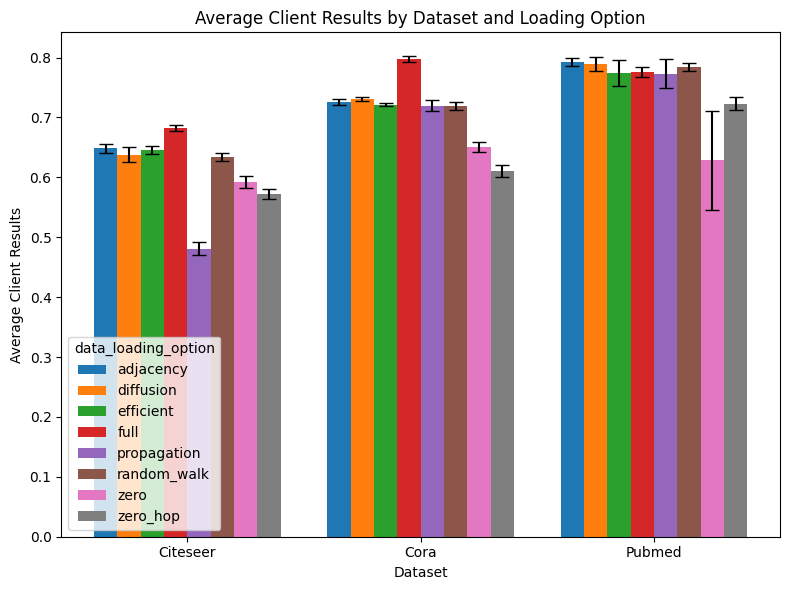

Results Table:


dataset,Citeseer,Cora,Pubmed
data_loading_option,,,
adjacency,0.648 ± 0.007,0.726 ± 0.005,0.792 ± 0.007
diffusion,0.638 ± 0.013,0.731 ± 0.004,0.789 ± 0.012
efficient,0.646 ± 0.006,0.721 ± 0.003,0.775 ± 0.022
full,0.682 ± 0.005,0.797 ± 0.005,0.776 ± 0.008
propagation,0.481 ± 0.011,0.720 ± 0.010,0.773 ± 0.025
random_walk,0.634 ± 0.007,0.719 ± 0.007,0.784 ± 0.007
zero,0.593 ± 0.010,0.651 ± 0.008,0.629 ± 0.083
zero_hop,0.572 ± 0.008,0.611 ± 0.010,0.723 ± 0.011


In [40]:
# plot the results table
results_table = plot_client_results(df_iid_2)
print("Results Table:")
results_table
# lets transpose the results table
results_table = results_table.T
results_table

/tmp/ipykernel_3690687/2981493629.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[option_col] = df[option_col].astype(str)


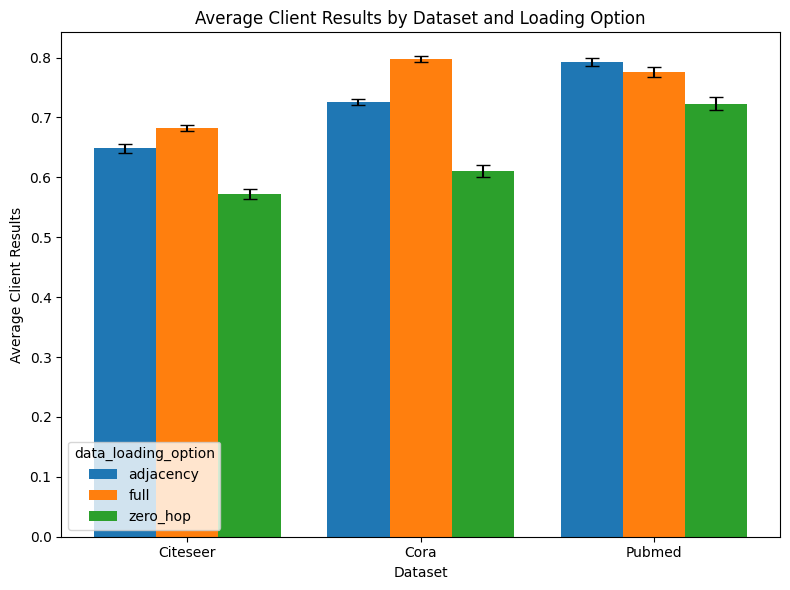

Results Table:


data_loading_option,adjacency,full,zero_hop
dataset,,,
Citeseer,0.648 ± 0.007,0.682 ± 0.005,0.572 ± 0.008
Cora,0.726 ± 0.005,0.797 ± 0.005,0.611 ± 0.010
Pubmed,0.792 ± 0.007,0.776 ± 0.008,0.723 ± 0.011


In [41]:
# lets filter results to keep the folowwing: data loading options: full, zero hop & adjacency
df_iid_2_filtered = df_iid_2[df_iid_2['data_loading_option'].isin(['full', 'zero_hop', 'adjacency'])]
df_iid_2_filtered
# plot the results table
results_table = plot_client_results(df_iid_2_filtered)
print("Results Table:")
results_table

### ogbn-arxiv


In [49]:
ogbn_arxiv_folder = "/home/brian_bosho/FP/FP/results/results_20250312_195224"
df_ogbn_arxiv = process_results_folder(ogbn_arxiv_folder)
df_ogbn_arxiv

# rename avg_client_result to avg_client_results
df_ogbn_arxiv.rename(columns={"avg_client_result": "avg_client_results"}, inplace=True)
df_ogbn_arxiv

Processed: /home/brian_bosho/FP/FP/results/results_20250312_195224/ogbn-arxiv_efficient_GCN/results_ogbn-arxiv_efficient_GCN_20250312_195745.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_195224/ogbn-arxiv_full_GCN/results_ogbn-arxiv_full_GCN_20250312_195539.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_195224/ogbn-arxiv_random_walk_GCN/results_ogbn-arxiv_random_walk_GCN_20250312_195711.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_195224/ogbn-arxiv_zero_hop_GCN/results_ogbn-arxiv_zero_hop_GCN_20250312_195355.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_195224/ogbn-arxiv_propagation_GCN/results_ogbn-arxiv_propagation_GCN_20250312_195505.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_195224/ogbn-arxiv_diffusion_GCN/results_ogbn-arxiv_diffusion_GCN_20250312_195635.json
Processed: /home/brian_bosho/FP/FP/results/results_20250312_195224/ogbn-arxiv_zero_GCN/results_ogbn-arxiv_zero_GCN_20250312_1954

,device,data_loading_option,model_type,dataset,num_clients,beta,hop,avg_global_result,avg_client_results,std_global,std_client,experiment_subfolder,json_filename,model_type_from_folder,final_round,final_global_result,final_client_result
0,cuda,efficient,GCN,ogbn-arxiv,10,1,2,NaN,NaN,NaN,NaN,ogbn-arxiv_efficient_GCN,results_ogbn-arxiv_efficient_GCN_20250312_1957...,GCN,NaN,NaN,NaN
1,cuda,full,GCN,ogbn-arxiv,10,1,2,NaN,NaN,NaN,NaN,ogbn-arxiv_full_GCN,results_ogbn-arxiv_full_GCN_20250312_195539.json,GCN,NaN,NaN,NaN
2,cuda,random_walk,GCN,ogbn-arxiv,10,1,2,NaN,NaN,NaN,NaN,ogbn-arxiv_random_walk_GCN,results_ogbn-arxiv_random_walk_GCN_20250312_19...,GCN,NaN,NaN,NaN
3,cuda,zero_hop,GCN,ogbn-arxiv,10,1,2,0.215563,0.597407,0.0,0.00089,ogbn-arxiv_zero_hop_GCN,results_ogbn-arxiv_zero_hop_GCN_20250312_19535...,GCN,2.0,0.215563,0.598297
4,cuda,propagation,GCN,ogbn-arxiv,10,1,2,NaN,NaN,NaN,NaN,ogbn-arxiv_propagation_GCN,results_ogbn-arxiv_propagation_GCN_20250312_19...,GCN,NaN,NaN,NaN
5,cuda,diffusion,GCN,ogbn-arxiv,10,1,2,NaN,NaN,NaN,NaN,ogbn-arxiv_diffusion_GCN,results_ogbn-arxiv_diffusion_GCN_20250312_1956...,GCN,NaN,NaN,NaN
6,cuda,zero,GCN,ogbn-arxiv,10,1,2,NaN,NaN,NaN,NaN,ogbn-arxiv_zero_GCN,results_ogbn-arxiv_zero_GCN_20250312_195429.json,GCN,NaN,NaN,NaN
7,cuda,adjacency,GCN,ogbn-arxiv,10,1,2,NaN,NaN,NaN,NaN,ogbn-arxiv_adjacency_GCN,results_ogbn-arxiv_adjacency_GCN_20250312_1956...,GCN,NaN,NaN,NaN
